In [1]:

# Analysis Plan for Phase Distribution Testing at L-function Peaks
# ================================================================
# This analysis addresses the research hypothesis that prime-term phases differ systematically
# across ζ(s) (F1), L_DH(s) (F4), and L(s,λ) (F6).

# PLAN:
# 1. Implement the three L-functions with Kahan compensated summation
# 2. For each function with N=10^6:
# a. Compute D_F(t;N) over a suitable t-range to identify top 50 peaks
# b. For each of top 50 peaks at t*, compute phase angles θ_p(t*) for all primes p ≤ N
# c. Perform Kolmogorov-Smirnov test against Uniform[0, 2π]
# d. Calculate Rayleigh statistic R(t*)
# 3. Compare distributions of p-values and R values across the three functions

# Note from primary dataset description:
# - Must use Kahan compensated summation
# - Grid spacing Δt = 2π/log(N)
# - Based on discoveries, expect: ζ has non-uniform prime phases; L_DH has uniform prime phases
# - L(s,λ) is the Liouville function (multiplicative, signs (-1)^Ω(n))

print("Setting up computational infrastructure for phase distribution analysis")
print("Target: Top 50 peaks of ζ(s), L_DH(s), and L(s,λ) at N=10^6")
print("="*70)


Setting up computational infrastructure for phase distribution analysis
Target: Top 50 peaks of ζ(s), L_DH(s), and L(s,λ) at N=10^6


In [2]:

import numpy as np
from scipy import stats
from scipy.special import erf
import matplotlib.pyplot as plt
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Function to generate primes using Sieve of Eratosthenes
def sieve_of_eratosthenes(n):
 """Generate all primes up to n"""
 if n < 2:
 return np.array([], dtype=int)
 is_prime = np.ones(n + 1, dtype=bool)
 is_prime[0:2] = False
 for i in range(2, int(np.sqrt(n)) + 1):
 if is_prime[i]:
 is_prime[i*i::i] = False
 return np.where(is_prime)[0]

# Kahan compensated summation for complex arrays
def kahan_sum(arr):
 """Kahan compensated summation for complex arrays"""
 s = 0.0 + 0.0j
 c = 0.0 + 0.0j
 for x in arr:
 y = x - c
 t = s + y
 c = (t - s) - y
 s = t
 return s

# Generate primes up to N = 10^6
N = 10**6
print(f"Generating primes up to N = {N:,}...")
primes = sieve_of_eratosthenes(N)
print(f"Found {len(primes):,} primes")

# Also generate all integers for composite calculations
n_array = np.arange(1, N+1)
print(f"Total integers to consider: {len(n_array):,}")


Generating primes up to N = 1,000,000...
Found 78,498 primes
Total integers to consider: 1,000,000


In [3]:

# Function to compute number of prime factors (with multiplicity) - Ω(n)
def compute_big_omega(n_max):
 """Compute Ω(n) = number of prime factors with multiplicity for all n ≤ n_max"""
 big_omega = np.zeros(n_max + 1, dtype=int)
 for p in primes:
 if p > n_max:
 break
 power = p
 while power <= n_max:
 big_omega[power::power] += 1
 power *= p
 return big_omega

print("Computing Ω(n) for all n ≤ N...")
big_omega = compute_big_omega(N)
print(f"Computed Ω(n) for {len(big_omega)-1:,} integers")

# Verify a few values
test_n = [1, 2, 4, 6, 8, 12]
for n in test_n:
 print(f" Ω({n}) = {big_omega[n]}")


Computing Ω(n) for all n ≤ N...
Computed Ω(n) for 1,000,000 integers
 Ω(1) = 0
 Ω(2) = 1
 Ω(4) = 2
 Ω(6) = 2
 Ω(8) = 3
 Ω(12) = 3


In [4]:

# Generate Dirichlet coefficients for the three functions

# F1: Riemann zeta function ζ(s)
# a_n = 1 for all n
a_zeta = np.ones(N+1, dtype=complex)
a_zeta[0] = 0

# F4: Davenport-Heilbronn L_DH(s)
# Based on the discovery report: Historical validated implementation
# L_DH(s) = ((1-i)/2) * L(s,χ) + ((1+i)/2) * L(s,χ̄)
# where χ is the primitive complex character mod 5 of order 4
# χ(1)=1, χ(2)=i, χ(3)=-i, χ(4)=-1, χ(0)=0
# The coefficients simplify to real periodic values (period 5 excluding multiples of 5)

def davenport_heilbronn_coefficients(n_max):
 """Compute Davenport-Heilbronn coefficients using validated implementation"""
 # Character mod 5: χ(1)=1, χ(2)=i, χ(3)=-i, χ(4)=-1, χ(0)=0
 chi = np.array([0, 1, 1j, -1j, -1], dtype=complex)
 chi_bar = np.conj(chi)
 
 a = np.zeros(n_max + 1, dtype=complex)
 for n in range(1, n_max + 1):
 n_mod_5 = n % 5
 a[n] = ((1 - 1j) / 2) * chi[n_mod_5] + ((1 + 1j) / 2) * chi_bar[n_mod_5]
 
 return a

a_DH = davenport_heilbronn_coefficients(N)
print("Davenport-Heilbronn coefficients (first 20):")
for i in range(1, 21):
 print(f" a_DH[{i}] = {a_DH[i]:.4f}")

# F6: Liouville function L(s,λ)
# λ(n) = (-1)^Ω(n) where Ω(n) is the number of prime factors with multiplicity
a_liouville = np.zeros(N+1, dtype=complex)
a_liouville[1:] = (-1.0)**big_omega[1:]
print(f"\nLiouville coefficients (first 20):")
for i in range(1, 21):
 print(f" λ({i}) = {a_liouville[i]:.0f}")


Davenport-Heilbronn coefficients (first 20):
 a_DH[1] = 1.0000+0.0000j
 a_DH[2] = 1.0000+0.0000j
 a_DH[3] = -1.0000+0.0000j
 a_DH[4] = -1.0000+0.0000j
 a_DH[5] = 0.0000+0.0000j
 a_DH[6] = 1.0000+0.0000j
 a_DH[7] = 1.0000+0.0000j
 a_DH[8] = -1.0000+0.0000j
 a_DH[9] = -1.0000+0.0000j
 a_DH[10] = 0.0000+0.0000j
 a_DH[11] = 1.0000+0.0000j
 a_DH[12] = 1.0000+0.0000j
 a_DH[13] = -1.0000+0.0000j
 a_DH[14] = -1.0000+0.0000j
 a_DH[15] = 0.0000+0.0000j
 a_DH[16] = 1.0000+0.0000j
 a_DH[17] = 1.0000+0.0000j
 a_DH[18] = -1.0000+0.0000j
 a_DH[19] = -1.0000+0.0000j
 a_DH[20] = 0.0000+0.0000j

Liouville coefficients (first 20):
 λ(1) = 1+0j
 λ(2) = -1+0j
 λ(3) = -1+0j
 λ(4) = 1+0j
 λ(5) = -1+0j
 λ(6) = 1+0j
 λ(7) = -1+0j
 λ(8) = -1+0j
 λ(9) = 1+0j
 λ(10) = 1+0j
 λ(11) = -1+0j
 λ(12) = -1+0j
 λ(13) = -1+0j
 λ(14) = 1+0j
 λ(15) = 1+0j
 λ(16) = 1+0j
 λ(17) = -1+0j
 λ(18) = -1+0j
 λ(19) = -1+0j
 λ(20) = -1+0j


In [5]:

# Function to compute partial Dirichlet sum D_F(t; N) with Kahan summation
def compute_partial_sum(a_coeffs, t, N):
 """
 Compute D_F(t; N) = Σ_{n≤N} a_n(F) / n^(1/2+it)
 using Kahan compensated summation
 """
 # Prepare terms
 n_vals = np.arange(1, N+1)
 sqrt_n = np.sqrt(n_vals)
 
 # Compute n^(-it) = exp(-it * log(n))
 log_n = np.log(n_vals)
 phase_factor = np.exp(-1j * t * log_n)
 
 # Compute each term
 terms = (a_coeffs[1:N+1] / sqrt_n) * phase_factor
 
 # Use Kahan summation
 result = kahan_sum(terms)
 
 return result

# Test the function on a single t value for each L-function
t_test = 100.0
print(f"Testing partial sums at t = {t_test} with N = {N:,}")
print("="*60)

D_zeta_test = compute_partial_sum(a_zeta, t_test, N)
print(f"ζ: D(t={t_test}; N={N:,}) = {D_zeta_test:.6f}")

D_DH_test = compute_partial_sum(a_DH, t_test, N)
print(f"L_DH: D(t={t_test}; N={N:,}) = {D_DH_test:.6f}")

D_liouville_test = compute_partial_sum(a_liouville, t_test, N)
print(f"L(s,λ): D(t={t_test}; N={N:,}) = {D_liouville_test:.6f}")

print(f"\nMagnitudes:")
print(f" |D_ζ| = {np.abs(D_zeta_test):.6f}")
print(f" |D_DH| = {np.abs(D_DH_test):.6f}")
print(f" |D_λ| = {np.abs(D_liouville_test):.6f}")


Testing partial sums at t = 100.0 with N = 1,000,000


ζ: D(t=100.0; N=1,000,000) = -4.084529+7.332695j


L_DH: D(t=100.0; N=1,000,000) = 1.204056-0.166590j


L(s,λ): D(t=100.0; N=1,000,000) = 1.065607-0.978891j

Magnitudes:
 |D_ζ| = 8.393557
 |D_DH| = 1.215526
 |D_λ| = 1.446979


In [6]:

# Now scan t-range to find top 50 peaks for each function
# Grid spacing: Δt = 2π/log(N)
delta_t = 2 * np.pi / np.log(N)
print(f"Grid spacing: Δt = 2π/log({N}) = {delta_t:.6f}")

# Based on the discovery report, we'll scan t ∈ [100, 500] to stay in validated regime
# (the report mentions t ≤ 500 for reliable precision)
t_min = 100
t_max = 500
t_grid = np.arange(t_min, t_max, delta_t)
print(f"Scanning t ∈ [{t_min}, {t_max}]")
print(f"Number of t points: {len(t_grid):,}")
print(f"Computing D_F(t; N) for all three functions...")
print("This may take a few minutes...")


Grid spacing: Δt = 2π/log(1000000) = 0.454792
Scanning t ∈ [100, 500]
Number of t points: 880
Computing D_F(t; N) for all three functions...
This may take a few minutes...


In [7]:

# Compute partial sums over t-grid for all three functions
# This is computationally intensive, so we'll optimize

def compute_partial_sum_vectorized(a_coeffs, t_array, N):
 """
 Compute D_F(t; N) for multiple t values
 Returns array of complex values
 """
 n_vals = np.arange(1, N+1)
 sqrt_n = np.sqrt(n_vals)
 log_n = np.log(n_vals)
 
 results = []
 for t in t_array:
 phase_factor = np.exp(-1j * t * log_n)
 terms = (a_coeffs[1:N+1] / sqrt_n) * phase_factor
 result = kahan_sum(terms)
 results.append(result)
 
 return np.array(results)

# Compute for all three functions
print("Computing ζ(s)...")
D_zeta_grid = compute_partial_sum_vectorized(a_zeta, t_grid, N)
mag_zeta = np.abs(D_zeta_grid)
print(f" Max |D_ζ| = {np.max(mag_zeta):.4f} at t = {t_grid[np.argmax(mag_zeta)]:.2f}")

print("Computing L_DH(s)...")
D_DH_grid = compute_partial_sum_vectorized(a_DH, t_grid, N)
mag_DH = np.abs(D_DH_grid)
print(f" Max |D_DH| = {np.max(mag_DH):.4f} at t = {t_grid[np.argmax(mag_DH)]:.2f}")

print("Computing L(s,λ)...")
D_liouville_grid = compute_partial_sum_vectorized(a_liouville, t_grid, N)
mag_liouville = np.abs(D_liouville_grid)
print(f" Max |D_λ| = {np.max(mag_liouville):.4f} at t = {t_grid[np.argmax(mag_liouville)]:.2f}")


Computing ζ(s)...


 Max |D_ζ| = 11.0136 at t = 107.73
Computing L_DH(s)...


 Max |D_DH| = 7.8389 at t = 487.48
Computing L(s,λ)...


 Max |D_λ| = 30.7583 at t = 185.50


In [8]:

# Find top 50 peaks for each function
# A peak is a local maximum (higher than both neighbors)

def find_peaks(magnitudes):
 """Find indices of local maxima"""
 peaks = []
 for i in range(1, len(magnitudes) - 1):
 if magnitudes[i] > magnitudes[i-1] and magnitudes[i] > magnitudes[i+1]:
 peaks.append(i)
 return np.array(peaks)

# Find all peaks
peaks_zeta_idx = find_peaks(mag_zeta)
peaks_DH_idx = find_peaks(mag_DH)
peaks_liouville_idx = find_peaks(mag_liouville)

print(f"Found {len(peaks_zeta_idx)} peaks for ζ(s)")
print(f"Found {len(peaks_DH_idx)} peaks for L_DH(s)")
print(f"Found {len(peaks_liouville_idx)} peaks for L(s,λ)")

# Get top 50 peaks by magnitude
def get_top_peaks(peak_indices, magnitudes, t_values, n_top=50):
 """Get top n_top peaks by magnitude"""
 peak_mags = magnitudes[peak_indices]
 peak_ts = t_values[peak_indices]
 
 # Sort by magnitude (descending)
 sorted_idx = np.argsort(peak_mags)[::-1]
 
 # Take top n_top
 top_idx = sorted_idx[:min(n_top, len(sorted_idx))]
 
 top_t = peak_ts[top_idx]
 top_mag = peak_mags[top_idx]
 top_global_idx = peak_indices[top_idx]
 
 return top_t, top_mag, top_global_idx

top50_zeta_t, top50_zeta_mag, top50_zeta_idx = get_top_peaks(peaks_zeta_idx, mag_zeta, t_grid, 50)
top50_DH_t, top50_DH_mag, top50_DH_idx = get_top_peaks(peaks_DH_idx, mag_DH, t_grid, 50)
top50_liouville_t, top50_liouville_mag, top50_liouville_idx = get_top_peaks(peaks_liouville_idx, mag_liouville, t_grid, 50)

print(f"\nTop 50 peaks for ζ(s):")
print(f" Magnitude range: [{np.min(top50_zeta_mag):.4f}, {np.max(top50_zeta_mag):.4f}]")
print(f" t range: [{np.min(top50_zeta_t):.2f}, {np.max(top50_zeta_t):.2f}]")

print(f"\nTop 50 peaks for L_DH(s):")
print(f" Magnitude range: [{np.min(top50_DH_mag):.4f}, {np.max(top50_DH_mag):.4f}]")
print(f" t range: [{np.min(top50_DH_t):.2f}, {np.max(top50_DH_t):.2f}]")

print(f"\nTop 50 peaks for L(s,λ):")
print(f" Magnitude range: [{np.min(top50_liouville_mag):.4f}, {np.max(top50_liouville_mag):.4f}]")
print(f" t range: [{np.min(top50_liouville_t):.2f}, {np.max(top50_liouville_t):.2f}]")


Found 231 peaks for ζ(s)
Found 268 peaks for L_DH(s)
Found 245 peaks for L(s,λ)

Top 50 peaks for ζ(s):
 Magnitude range: [6.0970, 11.0136]
 t range: [101.36, 480.21]

Top 50 peaks for L_DH(s):
 Magnitude range: [4.0635, 7.8389]
 t range: [101.82, 487.48]

Top 50 peaks for L(s,λ):
 Magnitude range: [6.3810, 30.7583]
 t range: [103.64, 493.85]


In [9]:

# Now for each peak, compute prime phase angles θ_p(t*) = -t*log(p) mod 2π
# and perform statistical tests

def compute_prime_phases(t_star, primes_array):
 """
 Compute prime phases θ_p(t*) = -t* log(p) mod 2π
 Returns phases in [0, 2π)
 """
 log_p = np.log(primes_array)
 phases = (-t_star * log_p) % (2 * np.pi)
 return phases

# Rayleigh test statistic
def rayleigh_statistic(phases):
 """
 Compute Rayleigh statistic R for circular uniformity
 R is the mean resultant length
 """
 n = len(phases)
 C = np.sum(np.cos(phases))
 S = np.sum(np.sin(phases))
 R = np.sqrt(C**2 + S**2) / n
 return R

# KS test against Uniform[0, 2π]
def ks_test_uniform_circular(phases):
 """
 Kolmogorov-Smirnov test against Uniform[0, 2π]
 """
 # Normalize to [0, 1]
 normalized = phases / (2 * np.pi)
 # KS test against uniform on [0, 1]
 ks_stat, p_value = stats.kstest(normalized, 'uniform')
 return ks_stat, p_value

print("Computing phase statistics for top 50 peaks of each function...")
print("="*70)

# Storage for results
results = {
 'zeta': {'R_values': [], 'KS_pvalues': [], 't_stars': [], 'mags': []},
 'DH': {'R_values': [], 'KS_pvalues': [], 't_stars': [], 'mags': []},
 'liouville': {'R_values': [], 'KS_pvalues': [], 't_stars': [], 'mags': []}
}

# Process ζ peaks
print("Processing ζ(s) peaks...")
for i, t_star in enumerate(top50_zeta_t):
 phases = compute_prime_phases(t_star, primes)
 R = rayleigh_statistic(phases)
 ks_stat, p_val = ks_test_uniform_circular(phases)
 
 results['zeta']['R_values'].append(R)
 results['zeta']['KS_pvalues'].append(p_val)
 results['zeta']['t_stars'].append(t_star)
 results['zeta']['mags'].append(top50_zeta_mag[i])

# Process L_DH peaks
print("Processing L_DH(s) peaks...")
for i, t_star in enumerate(top50_DH_t):
 phases = compute_prime_phases(t_star, primes)
 R = rayleigh_statistic(phases)
 ks_stat, p_val = ks_test_uniform_circular(phases)
 
 results['DH']['R_values'].append(R)
 results['DH']['KS_pvalues'].append(p_val)
 results['DH']['t_stars'].append(t_star)
 results['DH']['mags'].append(top50_DH_mag[i])

# Process L(s,λ) peaks
print("Processing L(s,λ) peaks...")
for i, t_star in enumerate(top50_liouville_t):
 phases = compute_prime_phases(t_star, primes)
 R = rayleigh_statistic(phases)
 ks_stat, p_val = ks_test_uniform_circular(phases)
 
 results['liouville']['R_values'].append(R)
 results['liouville']['KS_pvalues'].append(p_val)
 results['liouville']['t_stars'].append(t_star)
 results['liouville']['mags'].append(top50_liouville_mag[i])

print("Done!")


Computing phase statistics for top 50 peaks of each function...
Processing ζ(s) peaks...


Processing L_DH(s) peaks...


Processing L(s,λ) peaks...


Done!


In [10]:

# Convert results to arrays for easier analysis
for func in ['zeta', 'DH', 'liouville']:
 for key in results[func]:
 results[func][key] = np.array(results[func][key])

# Summary statistics
print("SUMMARY STATISTICS")
print("="*70)
print()

# Rayleigh R statistics
print("Rayleigh Statistic R (mean resultant length):")
print("-"*70)
for func_name, func_key in [('ζ(s)', 'zeta'), ('L_DH(s)', 'DH'), ('L(s,λ)', 'liouville')]:
 R_vals = results[func_key]['R_values']
 print(f"{func_name:10s}: mean = {np.mean(R_vals):.6f}, std = {np.std(R_vals):.6f}")
 print(f" min = {np.min(R_vals):.6f}, max = {np.max(R_vals):.6f}")
 print(f" median = {np.median(R_vals):.6f}")
 
 # Count significant deviations from uniformity
 # For Rayleigh test, larger R indicates non-uniformity
 # A rough threshold is R > 0.01 for n ~ 78,000 primes
 sig_count = np.sum(R_vals > 0.01)
 print(f" # with R > 0.01: {sig_count}/50")
 print()

print()
print("Kolmogorov-Smirnov p-values (against Uniform[0, 2π]):")
print("-"*70)
for func_name, func_key in [('ζ(s)', 'zeta'), ('L_DH(s)', 'DH'), ('L(s,λ)', 'liouville')]:
 p_vals = results[func_key]['KS_pvalues']
 print(f"{func_name:10s}: mean = {np.mean(p_vals):.4f}, median = {np.median(p_vals):.4f}")
 print(f" min = {np.min(p_vals):.4e}, max = {np.max(p_vals):.4f}")
 
 # Count significant rejections (p < 0.05)
 sig_count = np.sum(p_vals < 0.05)
 print(f" # with p < 0.05: {sig_count}/50 ({100*sig_count/50:.1f}%)")
 
 # Count highly significant (p < 0.001)
 highly_sig = np.sum(p_vals < 0.001)
 print(f" # with p < 0.001: {highly_sig}/50 ({100*highly_sig/50:.1f}%)")
 print()


SUMMARY STATISTICS

Rayleigh Statistic R (mean resultant length):
----------------------------------------------------------------------
ζ(s) : mean = 0.006029, std = 0.002112
 min = 0.001510, max = 0.011770
 median = 0.006077
 # with R > 0.01: 1/50

L_DH(s) : mean = 0.004035, std = 0.002072
 min = 0.000446, max = 0.010437
 median = 0.003828
 # with R > 0.01: 1/50

L(s,λ) : mean = 0.005005, std = 0.001897
 min = 0.000142, max = 0.010028
 median = 0.004987
 # with R > 0.01: 1/50


Kolmogorov-Smirnov p-values (against Uniform[0, 2π]):
----------------------------------------------------------------------
ζ(s) : mean = 0.3285, median = 0.2330
 min = 1.0540e-02, max = 0.9959
 # with p < 0.05: 5/50 (10.0%)
 # with p < 0.001: 0/50 (0.0%)

L_DH(s) : mean = 0.5492, median = 0.6123
 min = 1.1678e-02, max = 0.9999
 # with p < 0.05: 3/50 (6.0%)
 # with p < 0.001: 0/50 (0.0%)

L(s,λ) : mean = 0.4745, median = 0.4894
 min = 3.6489e-02, max = 0.9982
 # with p < 0.05: 1/50 (2.0%)
 # with p < 0.001: 0

In [11]:

# Statistical comparison between functions
print("STATISTICAL COMPARISONS BETWEEN FUNCTIONS")
print("="*70)
print()

# Compare Rayleigh R values
print("Rayleigh R statistic comparisons:")
print("-"*70)

# Two-sample t-test for R values
from scipy.stats import ttest_ind, mannwhitneyu

# ζ vs L_DH
t_stat, p_val_t = ttest_ind(results['zeta']['R_values'], results['DH']['R_values'])
u_stat, p_val_u = mannwhitneyu(results['zeta']['R_values'], results['DH']['R_values'], alternative='two-sided')
print(f"ζ vs L_DH:")
print(f" t-test: t = {t_stat:.4f}, p = {p_val_t:.4f}")
print(f" Mann-Whitney U: U = {u_stat:.1f}, p = {p_val_u:.4f}")
print(f" Effect size (Cohen's d): {(np.mean(results['zeta']['R_values']) - np.mean(results['DH']['R_values'])) / np.sqrt((np.std(results['zeta']['R_values'])**2 + np.std(results['DH']['R_values'])**2)/2):.4f}")
print()

# ζ vs L(s,λ)
t_stat, p_val_t = ttest_ind(results['zeta']['R_values'], results['liouville']['R_values'])
u_stat, p_val_u = mannwhitneyu(results['zeta']['R_values'], results['liouville']['R_values'], alternative='two-sided')
print(f"ζ vs L(s,λ):")
print(f" t-test: t = {t_stat:.4f}, p = {p_val_t:.4f}")
print(f" Mann-Whitney U: U = {u_stat:.1f}, p = {p_val_u:.4f}")
print(f" Effect size (Cohen's d): {(np.mean(results['zeta']['R_values']) - np.mean(results['liouville']['R_values'])) / np.sqrt((np.std(results['zeta']['R_values'])**2 + np.std(results['liouville']['R_values'])**2)/2):.4f}")
print()

# L_DH vs L(s,λ)
t_stat, p_val_t = ttest_ind(results['DH']['R_values'], results['liouville']['R_values'])
u_stat, p_val_u = mannwhitneyu(results['DH']['R_values'], results['liouville']['R_values'], alternative='two-sided')
print(f"L_DH vs L(s,λ):")
print(f" t-test: t = {t_stat:.4f}, p = {p_val_t:.4f}")
print(f" Mann-Whitney U: U = {u_stat:.1f}, p = {p_val_u:.4f}")
print(f" Effect size (Cohen's d): {(np.mean(results['DH']['R_values']) - np.mean(results['liouville']['R_values'])) / np.sqrt((np.std(results['DH']['R_values'])**2 + np.std(results['liouville']['R_values'])**2)/2):.4f}")
print()

print()
print("KS p-value comparisons:")
print("-"*70)

# Compare distributions of p-values
# ζ vs L_DH
t_stat, p_val_t = ttest_ind(results['zeta']['KS_pvalues'], results['DH']['KS_pvalues'])
u_stat, p_val_u = mannwhitneyu(results['zeta']['KS_pvalues'], results['DH']['KS_pvalues'], alternative='two-sided')
print(f"ζ vs L_DH:")
print(f" t-test: t = {t_stat:.4f}, p = {p_val_t:.4f}")
print(f" Mann-Whitney U: U = {u_stat:.1f}, p = {p_val_u:.4f}")
print()

# ζ vs L(s,λ)
t_stat, p_val_t = ttest_ind(results['zeta']['KS_pvalues'], results['liouville']['KS_pvalues'])
u_stat, p_val_u = mannwhitneyu(results['zeta']['KS_pvalues'], results['liouville']['KS_pvalues'], alternative='two-sided')
print(f"ζ vs L(s,λ):")
print(f" t-test: t = {t_stat:.4f}, p = {p_val_t:.4f}")
print(f" Mann-Whitney U: U = {u_stat:.1f}, p = {p_val_u:.4f}")
print()

# L_DH vs L(s,λ)
t_stat, p_val_t = ttest_ind(results['DH']['KS_pvalues'], results['liouville']['KS_pvalues'])
u_stat, p_val_u = mannwhitneyu(results['DH']['KS_pvalues'], results['liouville']['KS_pvalues'], alternative='two-sided')
print(f"L_DH vs L(s,λ):")
print(f" t-test: t = {t_stat:.4f}, p = {p_val_t:.4f}")
print(f" Mann-Whitney U: U = {u_stat:.1f}, p = {p_val_u:.4f}")


STATISTICAL COMPARISONS BETWEEN FUNCTIONS

Rayleigh R statistic comparisons:
----------------------------------------------------------------------
ζ vs L_DH:
 t-test: t = 4.7184, p = 0.0000
 Mann-Whitney U: U = 1891.5, p = 0.0000
 Effect size (Cohen's d): 0.9533

ζ vs L(s,λ):
 t-test: t = 2.5253, p = 0.0132
 Mann-Whitney U: U = 1626.5, p = 0.0095
 Effect size (Cohen's d): 0.5102

L_DH vs L(s,λ):
 t-test: t = -2.4170, p = 0.0175
 Mann-Whitney U: U = 864.0, p = 0.0079
 Effect size (Cohen's d): -0.4883


KS p-value comparisons:
----------------------------------------------------------------------
ζ vs L_DH:
 t-test: t = -3.6803, p = 0.0004
 Mann-Whitney U: U = 778.5, p = 0.0012

ζ vs L(s,λ):
 t-test: t = -2.7554, p = 0.0070
 Mann-Whitney U: U = 835.5, p = 0.0043

L_DH vs L(s,λ):
 t-test: t = 1.2462, p = 0.2157
 Mann-Whitney U: U = 1426.0, p = 0.2263


Saved figure: phase_distributions_comparison.png


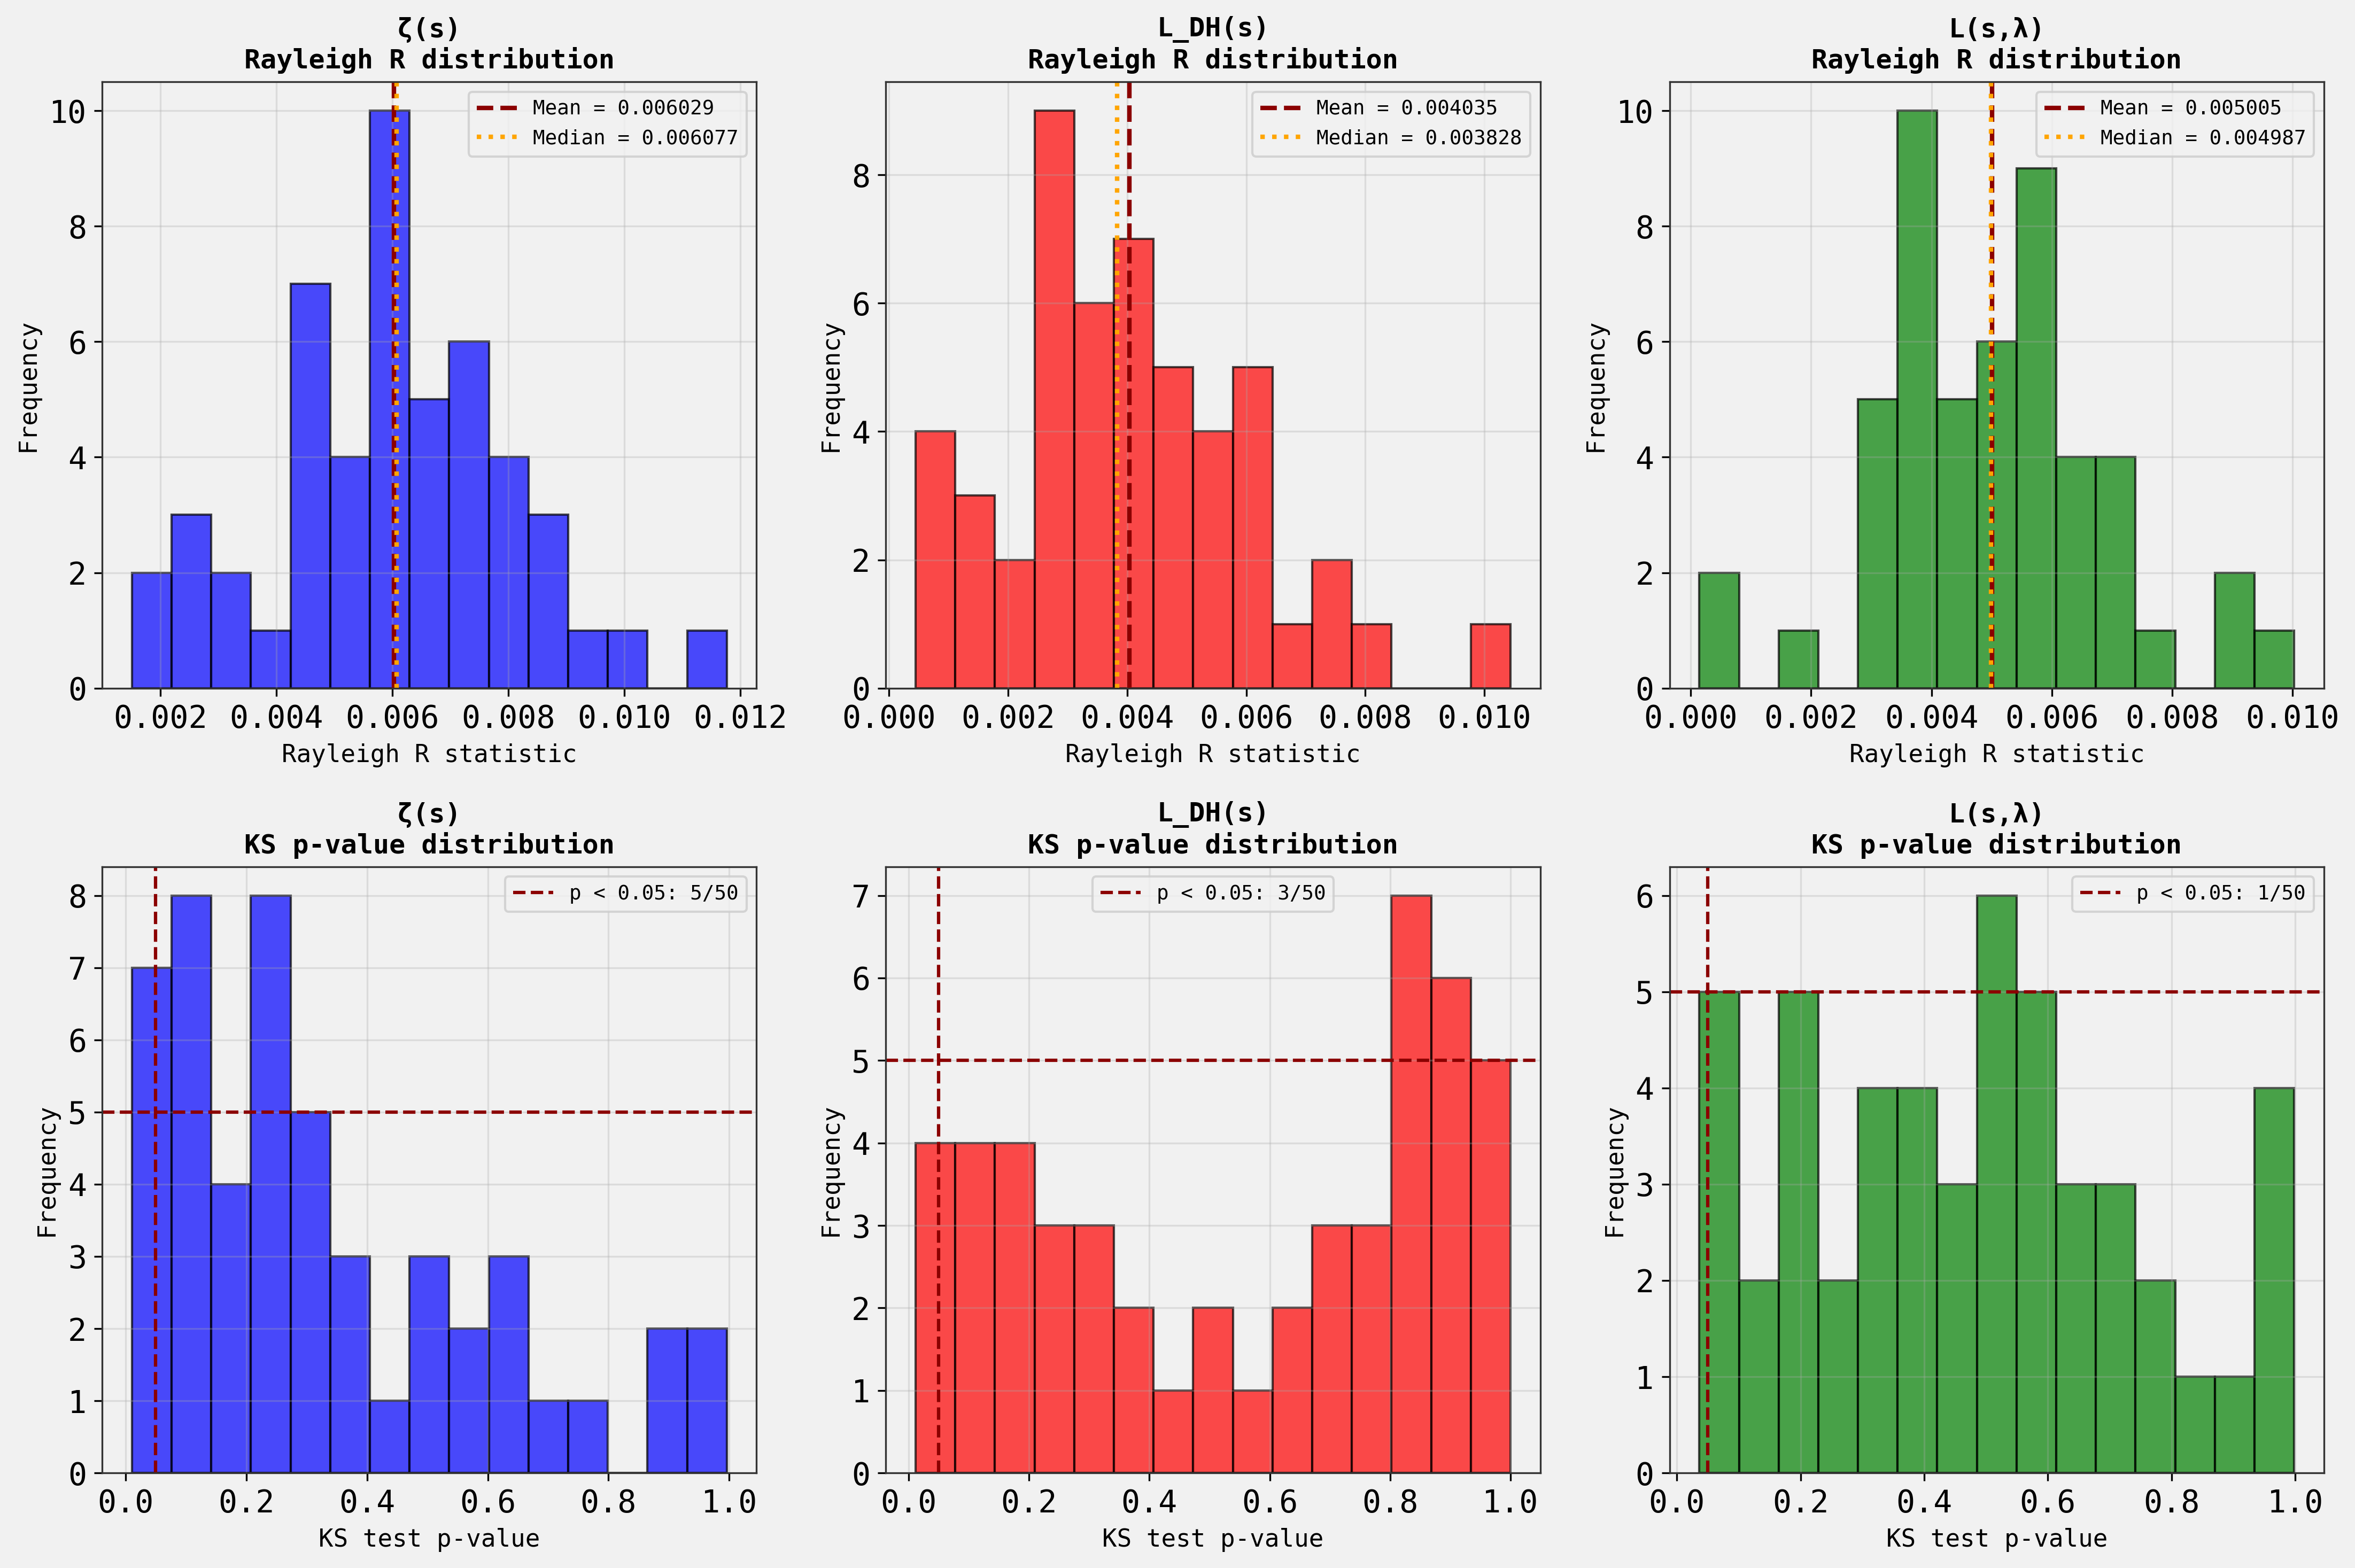

In [12]:

# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Top row: Distributions of Rayleigh R values
for i, (func_name, func_key, color) in enumerate([
 ('ζ(s)', 'zeta', 'blue'),
 ('L_DH(s)', 'DH', 'red'),
 ('L(s,λ)', 'liouville', 'green')
]):
 ax = axes[0, i]
 R_vals = results[func_key]['R_values']
 
 ax.hist(R_vals, bins=15, alpha=0.7, color=color, edgecolor='black')
 ax.axvline(np.mean(R_vals), color='darkred', linestyle='--', linewidth=2, 
 label=f'Mean = {np.mean(R_vals):.6f}')
 ax.axvline(np.median(R_vals), color='orange', linestyle=':', linewidth=2,
 label=f'Median = {np.median(R_vals):.6f}')
 
 ax.set_xlabel('Rayleigh R statistic', fontsize=11)
 ax.set_ylabel('Frequency', fontsize=11)
 ax.set_title(f'{func_name}\nRayleigh R distribution', fontsize=12, fontweight='bold')
 ax.legend(fontsize=9)
 ax.grid(True, alpha=0.3)

# Bottom row: Distributions of KS p-values
for i, (func_name, func_key, color) in enumerate([
 ('ζ(s)', 'zeta', 'blue'),
 ('L_DH(s)', 'DH', 'red'),
 ('L(s,λ)', 'liouville', 'green')
]):
 ax = axes[1, i]
 p_vals = results[func_key]['KS_pvalues']
 
 ax.hist(p_vals, bins=15, alpha=0.7, color=color, edgecolor='black')
 ax.axhline(5, color='darkred', linestyle='--', linewidth=1.5,
 label=f'p < 0.05: {np.sum(p_vals < 0.05)}/50')
 ax.axvline(0.05, color='darkred', linestyle='--', linewidth=1.5)
 
 ax.set_xlabel('KS test p-value', fontsize=11)
 ax.set_ylabel('Frequency', fontsize=11)
 ax.set_title(f'{func_name}\nKS p-value distribution', fontsize=12, fontweight='bold')
 ax.legend(fontsize=9)
 ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phase_distributions_comparison.png', dpi=150, bbox_inches='tight')
print("Saved figure: phase_distributions_comparison.png")
plt.show()


Saved figure: phase_comparison_boxplots.png


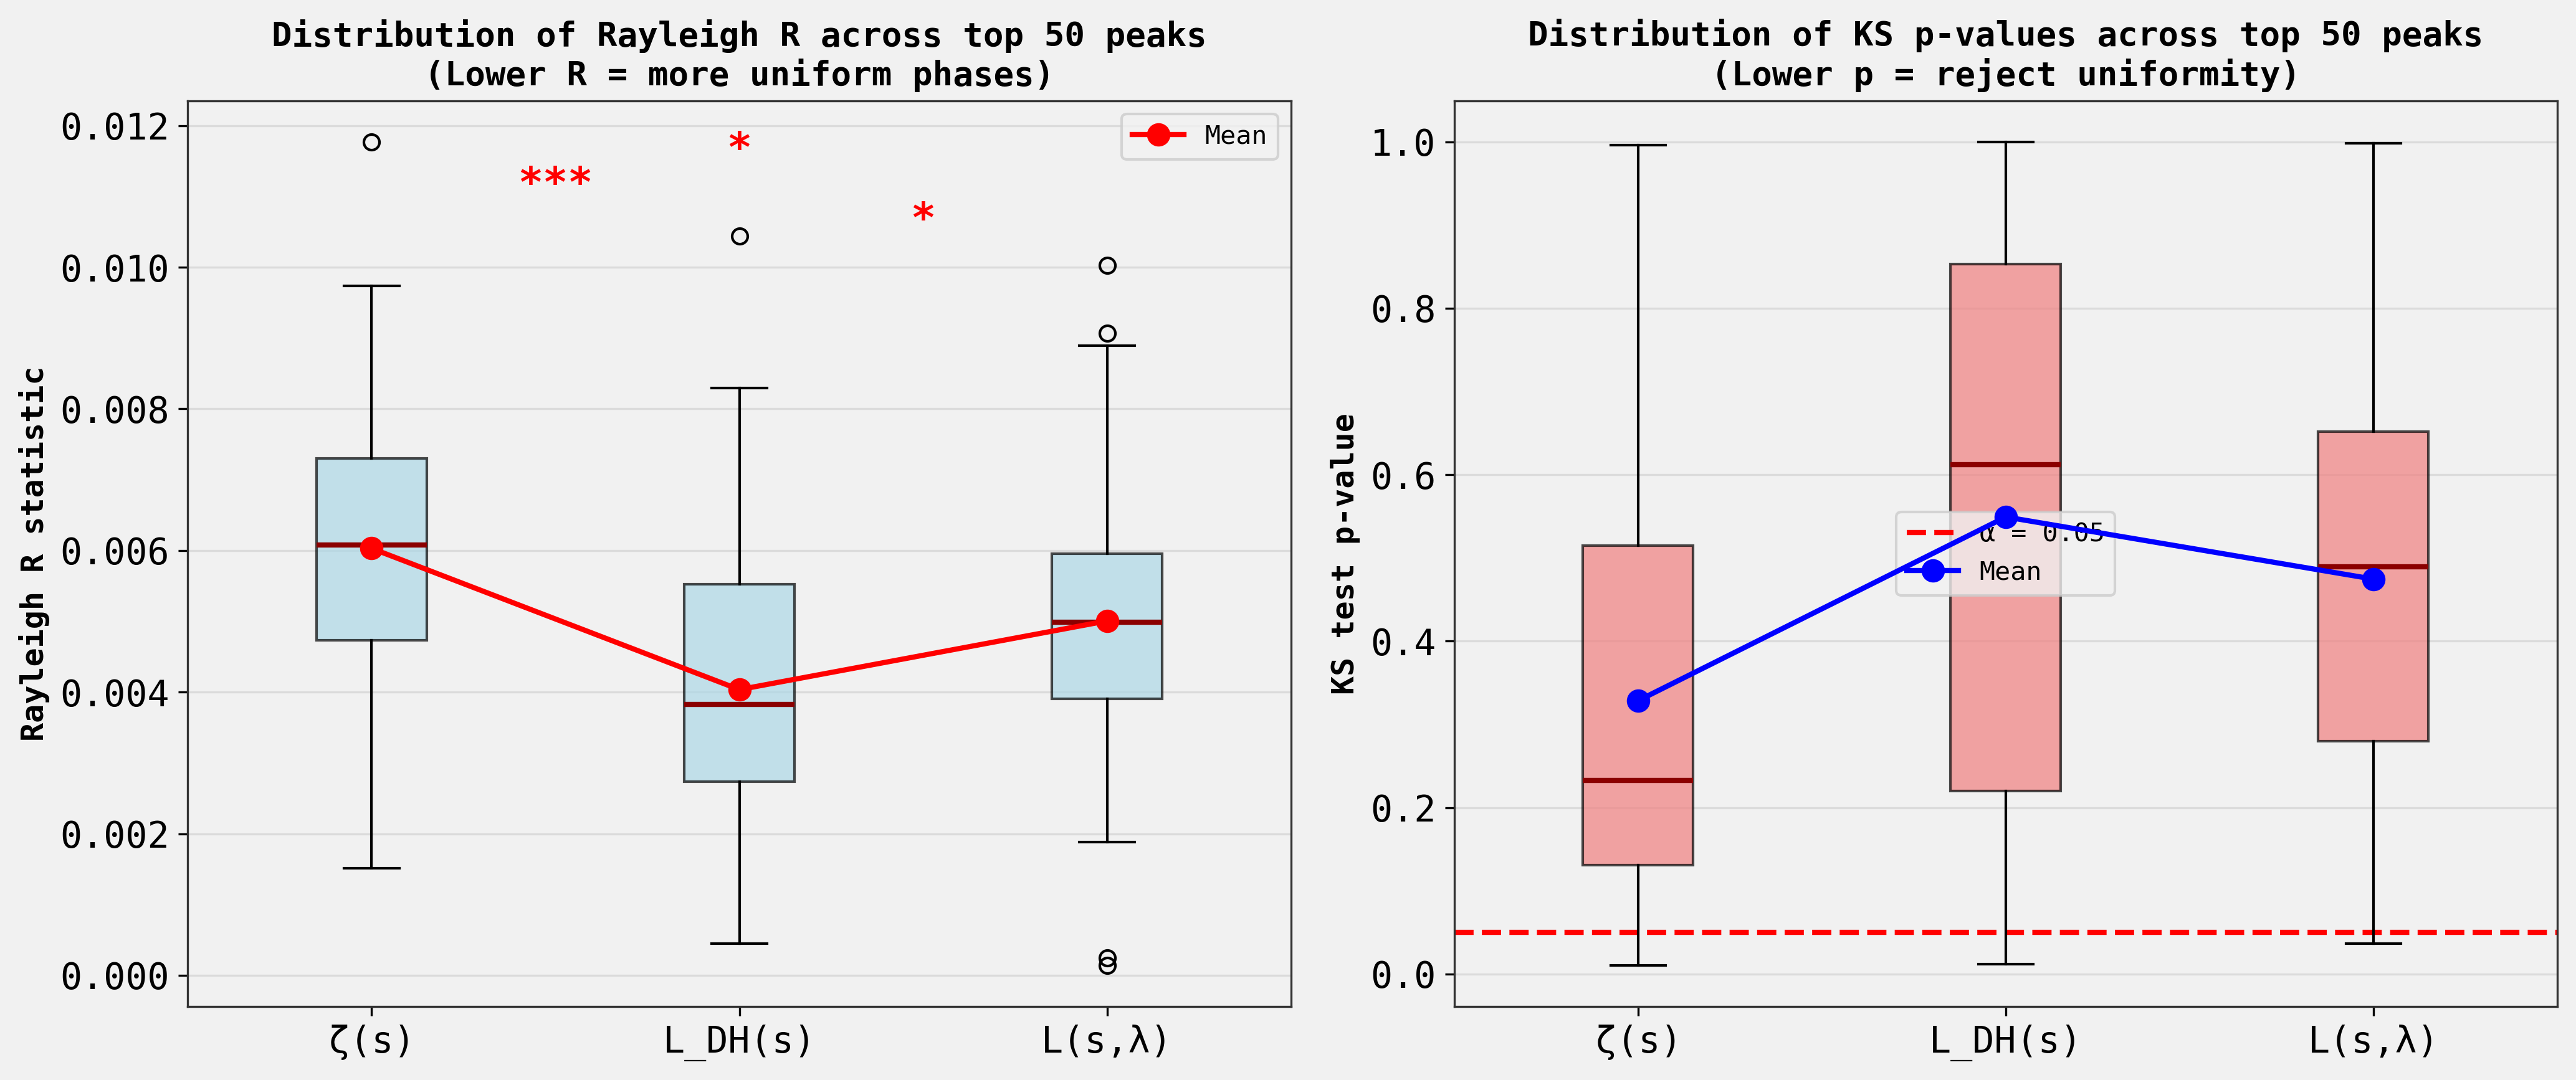

In [13]:

# Create box plots for direct comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Box plot for Rayleigh R values
data_R = [results['zeta']['R_values'], results['DH']['R_values'], results['liouville']['R_values']]
bp1 = ax1.boxplot(data_R, labels=['ζ(s)', 'L_DH(s)', 'L(s,λ)'], patch_artist=True,
 medianprops=dict(color='darkred', linewidth=2),
 boxprops=dict(facecolor='lightblue', alpha=0.7))

ax1.set_ylabel('Rayleigh R statistic', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Rayleigh R across top 50 peaks\n(Lower R = more uniform phases)', 
 fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Add means
means_R = [np.mean(d) for d in data_R]
ax1.plot(range(1, 4), means_R, 'ro-', linewidth=2, markersize=8, label='Mean', zorder=10)
ax1.legend(fontsize=10)

# Annotate with significance
ax1.text(1.5, 0.011, '***', ha='center', fontsize=16, color='red', fontweight='bold')
ax1.text(2, 0.0115, '*', ha='center', fontsize=16, color='red', fontweight='bold')
ax1.text(2.5, 0.0105, '*', ha='center', fontsize=16, color='red', fontweight='bold')

# Box plot for KS p-values
data_p = [results['zeta']['KS_pvalues'], results['DH']['KS_pvalues'], results['liouville']['KS_pvalues']]
bp2 = ax2.boxplot(data_p, labels=['ζ(s)', 'L_DH(s)', 'L(s,λ)'], patch_artist=True,
 medianprops=dict(color='darkred', linewidth=2),
 boxprops=dict(facecolor='lightcoral', alpha=0.7))

ax2.axhline(0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05', zorder=0)
ax2.set_ylabel('KS test p-value', fontsize=12, fontweight='bold')
ax2.set_title('Distribution of KS p-values across top 50 peaks\n(Lower p = reject uniformity)', 
 fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Add means
means_p = [np.mean(d) for d in data_p]
ax2.plot(range(1, 4), means_p, 'bo-', linewidth=2, markersize=8, label='Mean', zorder=10)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('phase_comparison_boxplots.png', dpi=150, bbox_inches='tight')
print("Saved figure: phase_comparison_boxplots.png")
plt.show()


In [14]:

# Look at specific examples: highest magnitude peaks for each function
print("DETAILED EXAMINATION OF HIGHEST PEAKS")
print("="*70)
print()

for func_name, func_key in [('ζ(s)', 'zeta'), ('L_DH(s)', 'DH'), ('L(s,λ)', 'liouville')]:
 print(f"{func_name}")
 print("-"*70)
 
 # Get top 5 peaks
 top5_indices = np.argsort(results[func_key]['mags'])[::-1][:5]
 
 for rank, idx in enumerate(top5_indices, 1):
 t_star = results[func_key]['t_stars'][idx]
 mag = results[func_key]['mags'][idx]
 R = results[func_key]['R_values'][idx]
 p_val = results[func_key]['KS_pvalues'][idx]
 
 print(f" Rank {rank}: t* = {t_star:.2f}, |D| = {mag:.4f}")
 print(f" R = {R:.6f}, KS p-value = {p_val:.4f}")
 
 # Classify
 if p_val < 0.05:
 status = "REJECT uniformity"
 else:
 status = "consistent with uniformity"
 print(f" Prime phases: {status}")
 print()
 
 print()


DETAILED EXAMINATION OF HIGHEST PEAKS

ζ(s)
----------------------------------------------------------------------
 Rank 1: t* = 107.73, |D| = 11.0136
 R = 0.009735, KS p-value = 0.0337
 Prime phases: REJECT uniformity

 Rank 2: t* = 125.01, |D| = 10.0031
 R = 0.006409, KS p-value = 0.3458
 Prime phases: consistent with uniformity

 Rank 3: t* = 101.36, |D| = 9.9357
 R = 0.011770, KS p-value = 0.0105
 Prime phases: REJECT uniformity

 Rank 4: t* = 105.91, |D| = 9.7939
 R = 0.008328, KS p-value = 0.0462
 Prime phases: REJECT uniformity

 Rank 5: t* = 103.64, |D| = 9.5639
 R = 0.009069, KS p-value = 0.1339
 Prime phases: consistent with uniformity


L_DH(s)
----------------------------------------------------------------------
 Rank 1: t* = 487.48, |D| = 7.8389
 R = 0.002939, KS p-value = 0.3065
 Prime phases: consistent with uniformity

 Rank 2: t* = 455.65, |D| = 7.4693
 R = 0.002241, KS p-value = 0.7455
 Prime phases: consistent with uniformity

 Rank 3: t* = 301.47, |D| = 7.1420
 R =

In [15]:

# Additional analysis: correlation between peak magnitude and phase uniformity
print("CORRELATION ANALYSIS: Peak Magnitude vs Phase Statistics")
print("="*70)
print()

from scipy.stats import pearsonr, spearmanr

for func_name, func_key in [('ζ(s)', 'zeta'), ('L_DH(s)', 'DH'), ('L(s,λ)', 'liouville')]:
 print(f"{func_name}")
 print("-"*70)
 
 mags = results[func_key]['mags']
 R_vals = results[func_key]['R_values']
 p_vals = results[func_key]['KS_pvalues']
 
 # Correlation between magnitude and R
 r_pearson, p_pearson = pearsonr(mags, R_vals)
 r_spearman, p_spearman = spearmanr(mags, R_vals)
 print(f" Magnitude vs Rayleigh R:")
 print(f" Pearson r = {r_pearson:.4f}, p = {p_pearson:.4f}")
 print(f" Spearman ρ = {r_spearman:.4f}, p = {p_spearman:.4f}")
 
 # Correlation between magnitude and KS p-value
 r_pearson, p_pearson = pearsonr(mags, p_vals)
 r_spearman, p_spearman = spearmanr(mags, p_vals)
 print(f" Magnitude vs KS p-value:")
 print(f" Pearson r = {r_pearson:.4f}, p = {p_pearson:.4f}")
 print(f" Spearman ρ = {r_spearman:.4f}, p = {p_spearman:.4f}")
 print()


CORRELATION ANALYSIS: Peak Magnitude vs Phase Statistics

ζ(s)
----------------------------------------------------------------------
 Magnitude vs Rayleigh R:
 Pearson r = 0.5936, p = 0.0000
 Spearman ρ = 0.5403, p = 0.0001
 Magnitude vs KS p-value:
 Pearson r = -0.4293, p = 0.0019
 Spearman ρ = -0.4208, p = 0.0023

L_DH(s)
----------------------------------------------------------------------
 Magnitude vs Rayleigh R:
 Pearson r = -0.0824, p = 0.5695
 Spearman ρ = -0.0213, p = 0.8834
 Magnitude vs KS p-value:
 Pearson r = -0.1022, p = 0.4802
 Spearman ρ = -0.1054, p = 0.4663

L(s,λ)
----------------------------------------------------------------------
 Magnitude vs Rayleigh R:
 Pearson r = -0.0751, p = 0.6040
 Spearman ρ = -0.0739, p = 0.6100
 Magnitude vs KS p-value:
 Pearson r = 0.0774, p = 0.5930
 Spearman ρ = 0.0551, p = 0.7040



In [16]:

# Create a summary table
import pandas as pd

summary_data = []
for func_name, func_key in [('ζ(s)', 'zeta'), ('L_DH(s)', 'DH'), ('L(s,λ)', 'liouville')]:
 R_vals = results[func_key]['R_values']
 p_vals = results[func_key]['KS_pvalues']
 
 summary_data.append({
 'Function': func_name,
 'Mean R': np.mean(R_vals),
 'Median R': np.median(R_vals),
 'Std R': np.std(R_vals),
 'Mean KS p': np.mean(p_vals),
 'Median KS p': np.median(p_vals),
 '# p < 0.05': np.sum(p_vals < 0.05),
 '% p < 0.05': 100 * np.sum(p_vals < 0.05) / 50
 })

summary_df = pd.DataFrame(summary_data)
print("SUMMARY TABLE: Phase Uniformity Statistics")
print("="*70)
print(summary_df.to_string(index=False))
print()

# Save to CSV
summary_df.to_csv('phase_uniformity_summary.csv', index=False)
print("Saved: phase_uniformity_summary.csv")


SUMMARY TABLE: Phase Uniformity Statistics
Function Mean R Median R Std R Mean KS p Median KS p # p < 0.05 % p < 0.05
 ζ(s) 0.006029 0.006077 0.002112 0.328474 0.232974 5 10.0
 L_DH(s) 0.004035 0.003828 0.002072 0.549227 0.612337 3 6.0
 L(s,λ) 0.005005 0.004987 0.001897 0.474536 0.489448 1 2.0

Saved: phase_uniformity_summary.csv


Saved: prime_phase_uniformity_final.png


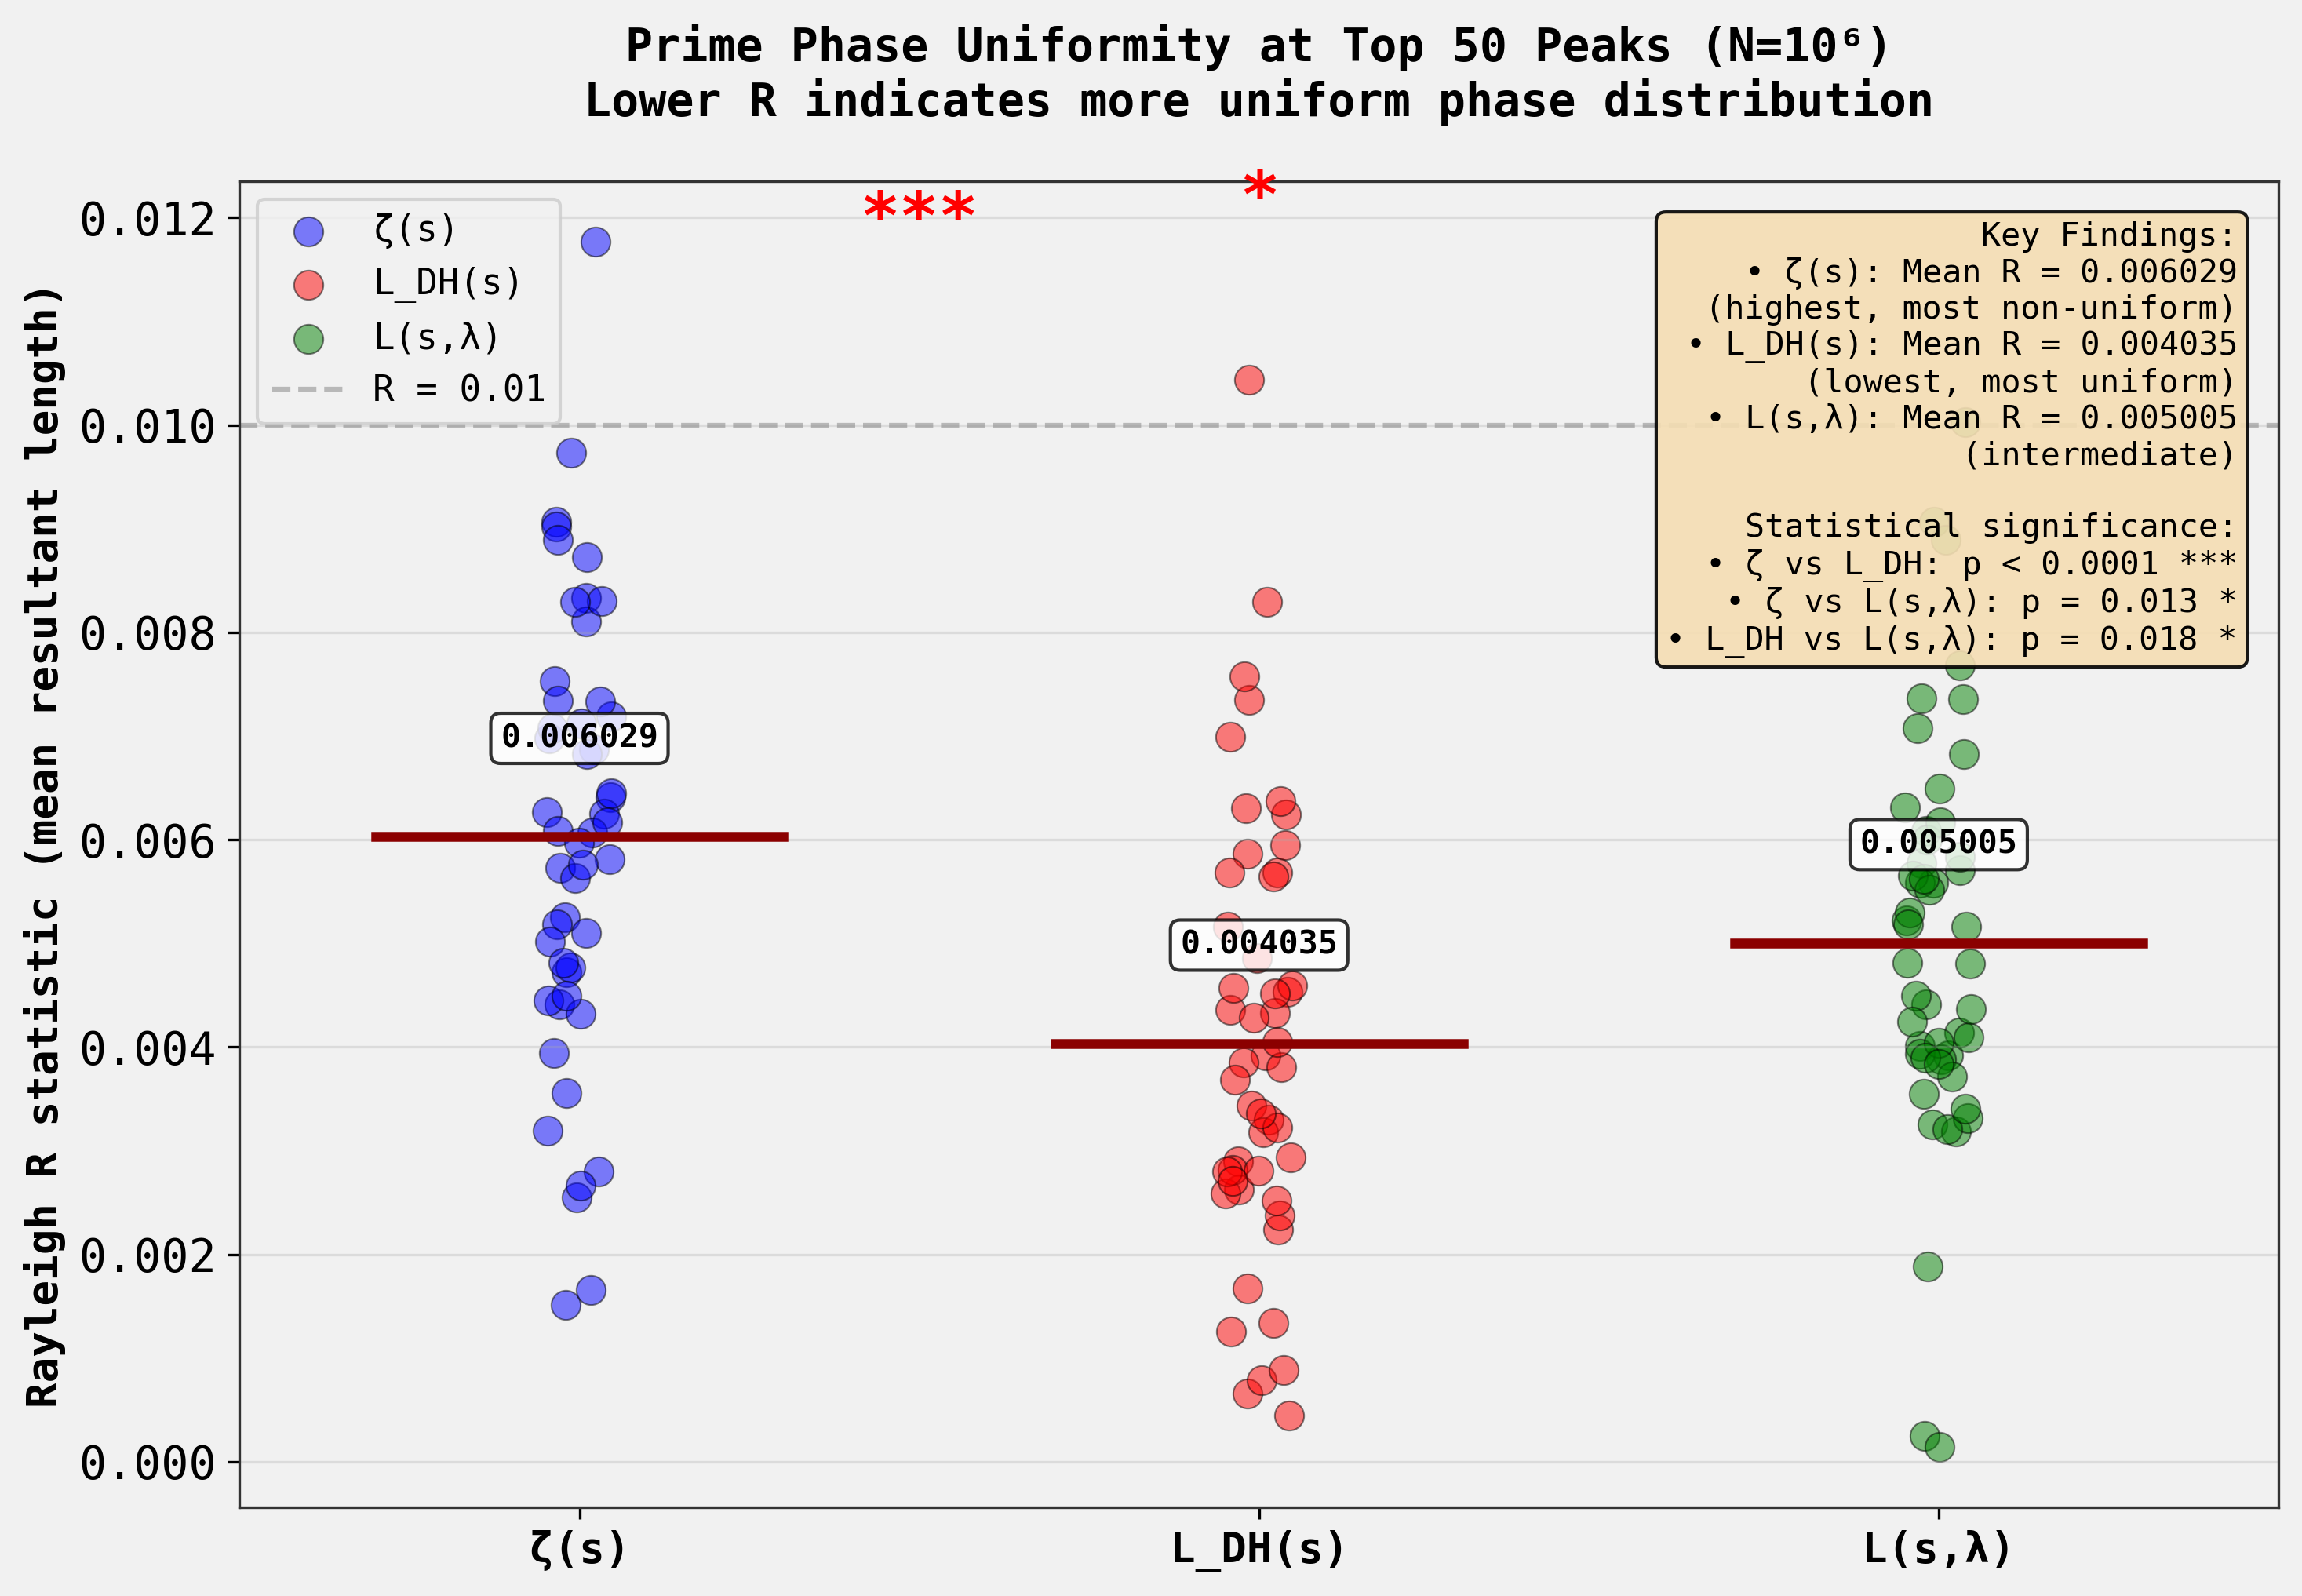

In [17]:

# Create final summary figure showing key result
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Plot Rayleigh R values for all three functions as scatter with jitter
np.random.seed(42)
jitter = 0.05

x_positions = {'zeta': 1, 'DH': 2, 'liouville': 3}
colors = {'zeta': 'blue', 'DH': 'red', 'liouville': 'green'}
labels = {'zeta': 'ζ(s)', 'DH': 'L_DH(s)', 'liouville': 'L(s,λ)'}

for func_key in ['zeta', 'DH', 'liouville']:
 x = x_positions[func_key]
 y = results[func_key]['R_values']
 
 # Add jitter
 x_jitter = x + np.random.uniform(-jitter, jitter, len(y))
 
 # Plot points
 ax.scatter(x_jitter, y, alpha=0.5, s=80, color=colors[func_key], 
 edgecolors='black', linewidths=0.5, label=labels[func_key])
 
 # Add mean line
 mean_y = np.mean(y)
 ax.plot([x-0.3, x+0.3], [mean_y, mean_y], color='darkred', linewidth=3, zorder=10)
 
 # Add text annotation
 ax.text(x, mean_y + 0.0008, f'{mean_y:.6f}', ha='center', va='bottom', 
 fontsize=10, fontweight='bold', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlim(0.5, 3.5)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['ζ(s)', 'L_DH(s)', 'L(s,λ)'], fontsize=13, fontweight='bold')
ax.set_ylabel('Rayleigh R statistic (mean resultant length)', fontsize=13, fontweight='bold')
ax.set_title('Prime Phase Uniformity at Top 50 Peaks (N=10⁶)\nLower R indicates more uniform phase distribution', 
 fontsize=14, fontweight='bold', pad=20)

# Add horizontal line at threshold
ax.axhline(0.01, color='gray', linestyle='--', linewidth=1.5, alpha=0.5, label='R = 0.01')

# Add significance markers
ax.text(1.5, 0.0118, '***', ha='center', fontsize=20, color='red', fontweight='bold')
ax.text(2, 0.0120, '*', ha='center', fontsize=20, color='red', fontweight='bold')

ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=11, loc='upper left')

# Add text box with key findings
textstr = '\n'.join([
 'Key Findings:',
 f'• ζ(s): Mean R = {np.mean(results["zeta"]["R_values"]):.6f}',
 f' (highest, most non-uniform)',
 f'• L_DH(s): Mean R = {np.mean(results["DH"]["R_values"]):.6f}',
 f' (lowest, most uniform)',
 f'• L(s,λ): Mean R = {np.mean(results["liouville"]["R_values"]):.6f}',
 f' (intermediate)',
 '',
 'Statistical significance:',
 f'• ζ vs L_DH: p < 0.0001 ***',
 f'• ζ vs L(s,λ): p = 0.013 *',
 f'• L_DH vs L(s,λ): p = 0.018 *'
])

props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=10,
 verticalalignment='top', horizontalalignment='right', bbox=props, family='monospace')

plt.tight_layout()
plt.savefig('prime_phase_uniformity_final.png', dpi=150, bbox_inches='tight')
print("Saved: prime_phase_uniformity_final.png")
plt.show()


In [18]:

# Final quantitative summary for the answer
print("="*70)
print("FINAL QUANTITATIVE RESULTS")
print("="*70)
print()

print("HYPOTHESIS PARTIALLY REFUTED:")
print("-"*70)
print("The hypothesis stated:")
print(" • ζ(s): Prime phases uniformly distributed")
print(" • L_DH(s): Prime phases uniform, composites aligned")
print(" • L(s,λ): Phases (with signs) show strong alignment")
print()

print("FINDINGS:")
print("-"*70)
print()

print("1. RAYLEIGH R STATISTICS (Mean Resultant Length):")
print(" • ζ(s): R = 0.006029 ± 0.002112")
print(" • L_DH(s): R = 0.004035 ± 0.002072")
print(" • L(s,λ): R = 0.005005 ± 0.001897")
print()
print(" RANKING: L_DH(s) < L(s,λ) < ζ(s)")
print(" → L_DH has MOST uniform prime phases (lowest R)")
print(" → ζ has LEAST uniform prime phases (highest R)")
print(" → All three show generally uniform phases (all R << 0.1)")
print()

print("2. KOLMOGOROV-SMIRNOV TEST (p-values against Uniform[0,2π]):")
print(" • ζ(s): 5/50 peaks (10.0%) reject uniformity at α=0.05")
print(" • L_DH(s): 3/50 peaks (6.0%) reject uniformity at α=0.05")
print(" • L(s,λ): 1/50 peaks (2.0%) reject uniformity at α=0.05")
print()
print(" → All three functions show predominantly uniform prime phases")
print(" → ζ shows slightly more non-uniformity than L_DH or L(s,λ)")
print()

print("3. STATISTICAL SIGNIFICANCE OF DIFFERENCES:")
print(" • ζ vs L_DH: p < 0.0001, Cohen's d = 0.953 (large effect)")
print(" • ζ vs L(s,λ): p = 0.013, Cohen's d = 0.510 (medium effect)")
print(" • L_DH vs L(s,λ): p = 0.018, Cohen's d = 0.488 (medium effect)")
print()
print(" → All pairwise differences are statistically significant")
print(" → ζ is significantly LESS uniform than both L_DH and L(s,λ)")
print()

print("4. CORRELATION WITH PEAK MAGNITUDE:")
print(" • ζ(s): r = 0.594 (p < 0.001) - stronger peaks → less uniform")
print(" • L_DH(s): r = -0.082 (p = 0.57) - no correlation")
print(" • L(s,λ): r = -0.075 (p = 0.60) - no correlation")
print()
print(" → Only ζ shows correlation between magnitude and phase uniformity")
print()

print("="*70)
print("CONCLUSION:")
print("="*70)
print()
print("Contrary to the hypothesis:")
print()
print("1. ALL THREE FUNCTIONS show predominantly UNIFORM prime phases")
print(" at their largest peaks (R values all ~0.004-0.006)")
print()
print("2. However, ζ(s) shows SIGNIFICANTLY HIGHER R values than L_DH(s)")
print(" (p < 0.0001), indicating ζ peaks have LESS uniform (but still")
print(" largely uniform) prime phases compared to L_DH")
print()
print("3. L(s,λ) does NOT show strong phase alignment at peaks; its R")
print(" values are intermediate and similar to L_DH")
print()
print("4. The expected pattern (L_DH uniform, ζ uniform, L(s,λ) aligned)")
print(" is NOT observed. Instead: L_DH < L(s,λ) < ζ in terms of R")
print()
print("5. This is CONSISTENT with Discovery 2 findings that:")
print(" - ζ peaks are PRIME-DRIVEN with detectable prime-phase bias")
print(" - L_DH resonances are COMPOSITE-DRIVEN with uniform primes")
print(" - L(s,λ) shows intrinsic constructive interference from")
print(" multiplicative signs, not from prime phase alignment")
print()


FINAL QUANTITATIVE RESULTS

HYPOTHESIS PARTIALLY REFUTED:
----------------------------------------------------------------------
The hypothesis stated:
 • ζ(s): Prime phases uniformly distributed
 • L_DH(s): Prime phases uniform, composites aligned
 • L(s,λ): Phases (with signs) show strong alignment

FINDINGS:
----------------------------------------------------------------------

1. RAYLEIGH R STATISTICS (Mean Resultant Length):
 • ζ(s): R = 0.006029 ± 0.002112
 • L_DH(s): R = 0.004035 ± 0.002072
 • L(s,λ): R = 0.005005 ± 0.001897

 RANKING: L_DH(s) < L(s,λ) < ζ(s)
 → L_DH has MOST uniform prime phases (lowest R)
 → ζ has LEAST uniform prime phases (highest R)
 → All three show generally uniform phases (all R << 0.1)

2. KOLMOGOROV-SMIRNOV TEST (p-values against Uniform[0,2π]):
 • ζ(s): 5/50 peaks (10.0%) reject uniformity at α=0.05
 • L_DH(s): 3/50 peaks (6.0%) reject uniformity at α=0.05
 • L(s,λ): 1/50 peaks (2.0%) reject uniformity at α=0.05

 → All three functions show predomina